In [2]:
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [3]:
X_train = pd.read_csv('X_train_ohe_int.csv')
X_test = pd.read_csv('X_test_ohe_int.csv')
y_train = pd.read_csv('y_train.csv').values.ravel()
y_test = pd.read_csv('y_test.csv').values.ravel()

In [4]:
# === 1) Model baseline XGBoost ===
xgb = XGBClassifier(
    # Booster yang digunakan, 'gbtree' paling umum untuk tabular data
    booster='gbtree',

    # Bobot untuk mengatasi imbalance kelas:
    # scale_pos_weight = (jumlah negatif / jumlah positif)
    scale_pos_weight=3,  # sesuaikan dengan rasio dataset-mu

    # Seed untuk reprodusibilitas
    random_state=42,

    # Gunakan semua core CPU
    n_jobs=-1
)

In [5]:
# === 2) Training ===
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=-1,
              num_parallel_tree=None, random_state=42, ...)

In [6]:

# === 3) Prediksi ===
y_pred = xgb.predict(X_test)

In [7]:
# === 4) Evaluasi ===
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, digits=3)
roc_auc = roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1])

print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", report)
print("ROC-AUC:", roc_auc)


Confusion Matrix:
 [[754 279]
 [114 260]]

Classification Report:
               precision    recall  f1-score   support

           0      0.869     0.730     0.793      1033
           1      0.482     0.695     0.570       374

    accuracy                          0.721      1407
   macro avg      0.676     0.713     0.681      1407
weighted avg      0.766     0.721     0.734      1407

ROC-AUC: 0.7908601705224905


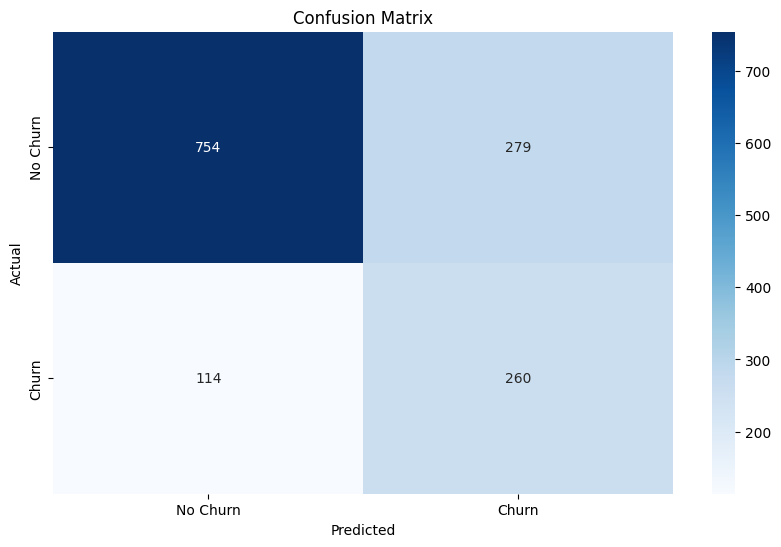

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
